## 1. Setup

In [1]:
import os, sys, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GroupKFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, spearmanr
import xgboost as xgb

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../"))
DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
RANDOM_STATE = 42

TARGET = "priority_rank"

print("Setup complete.")

Setup complete.


## 2. Load Data and Build Program-Cluster Rows

In [2]:
clustered = pd.read_csv(os.path.join(DATA_DIR, "executions_clustered.csv"))
raw = pd.read_csv(os.path.join(DATA_DIR, "executions.csv"))
assert "cluster" in clustered.columns, "Re-run 02_clustering.ipynb first."

raw_feats = pd.read_csv(os.path.join(DATA_DIR, "executions_features_raw.csv"))
clustering_scaler = joblib.load(os.path.join(MODELS_DIR, "clustering_scaler.joblib"))
scaled_values = clustering_scaler.transform(raw_feats)
scaled = pd.DataFrame(scaled_values, columns=raw_feats.columns, index=raw_feats.index)

row_level = raw.copy()
row_level["cluster"] = clustered["cluster"].astype(int)
scaled_prefixed = scaled.add_prefix("scaled_")
row_level = pd.concat([row_level, scaled_prefixed], axis=1)

print(f"Loaded {len(row_level)} rows with {len(scaled_prefixed.columns)} scaled features.")

Loaded 9400 rows with 23 scaled features.


## 3. Build cluster_frame & Target Check

In [3]:
prog_counts = row_level.groupby("program_id")["suggestion_id"].count().rename("program_suggestion_count")
cluster_frame = row_level.groupby(["program_id", "cluster"]).agg(
    cluster_suggestion_count=("suggestion_id", "count"),
    cluster_impact_sum=("impact_score", "sum"),
    cluster_impact_mean=("impact_score", "mean"),
).reset_index()

cluster_frame = cluster_frame.merge(prog_counts.reset_index(), on="program_id")
cluster_frame["cluster_share"] = cluster_frame["cluster_suggestion_count"] / cluster_frame["program_suggestion_count"]

cluster_frame["priority_rank"] = (
    cluster_frame
    .groupby("program_id")["cluster_impact_sum"]
    .rank(ascending=False, method="dense")
    .astype(int)
)

scaled_agg = row_level.groupby(["program_id", "cluster"])[scaled_prefixed.columns].mean().reset_index()
cluster_frame = cluster_frame.merge(scaled_agg, on=["program_id", "cluster"])

comp_map = (
    row_level.groupby("program_id")["pattern"]
    .apply(frozenset)
    .reset_index()
)
comp_map.columns = ["program_id", "composition"]
comp_map["archetype"] = comp_map["composition"].apply(lambda s: "_".join(sorted(s)))
cluster_frame = cluster_frame.merge(comp_map[["program_id", "archetype"]], on="program_id", how="left")
print(f"Computed {cluster_frame['archetype'].nunique()} unique archetypes across {cluster_frame['program_id'].nunique()} programs.")

print(f"\npriority_rank distribution:\n{cluster_frame['priority_rank'].value_counts().sort_index().to_string()}")
target_std = cluster_frame[TARGET].std()
print(f"Target '{TARGET}' range: [{cluster_frame[TARGET].min()}, {cluster_frame[TARGET].max()}] | Std: {target_std:.4f}")
if target_std < 0.5:
    print("WARNING: Target has near-zero variance — rank distribution is too narrow.")

Computed 9 unique archetypes across 2000 programs.

priority_rank distribution:
priority_rank
1    2200
2    2800
3    2600
4     200
Target 'priority_rank' range: [1, 4] | Std: 0.8411


## 4. Target Distribution

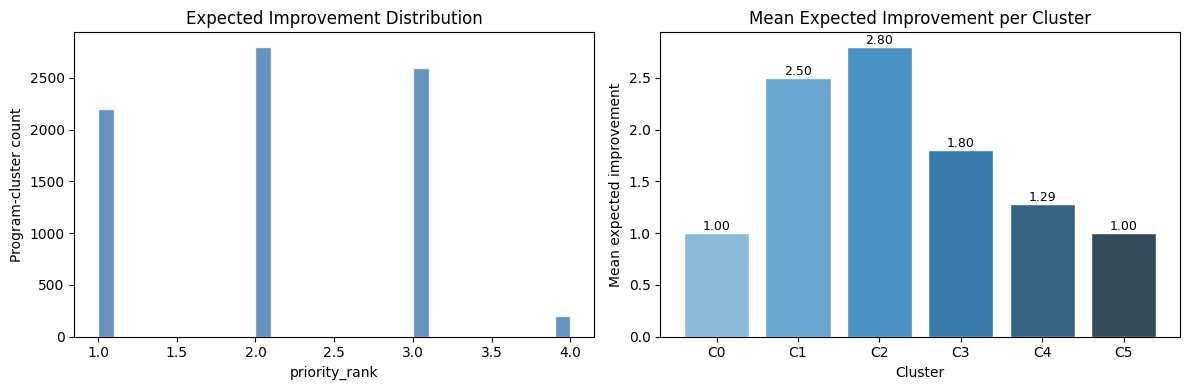

Mean improvement by cluster:
cluster
0    1.0000
1    2.5000
2    2.8000
3    1.8000
4    1.2857
5    1.0000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cluster_frame[TARGET], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Expected Improvement Distribution", fontsize=12)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel("Program-cluster count")

cluster_target = cluster_frame.groupby("cluster")[TARGET].mean().sort_index()
axes[1].bar([f"C{i}" for i in cluster_target.index], cluster_target.values,
            color=sns.color_palette("Blues_d", len(cluster_target)), edgecolor="white")
axes[1].set_title("Mean Expected Improvement per Cluster", fontsize=12)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Mean expected improvement")
for bar, val in zip(axes[1].patches, cluster_target.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.2f}", 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "target_distribution.png"), dpi=150)
plt.show()
print(f"Mean improvement by cluster:\n{cluster_target.round(4).to_string()}")

## 5: Explicit Feature Definition & Program-Level Split

In [5]:
CLUSTER_AGGS = [
    "cluster", "cluster_suggestion_count", "cluster_share",
    "program_suggestion_count"
]
SCALED_FEAT_COLS = [c for c in cluster_frame.columns if c.startswith("scaled_")]

safe_scaled = [c for c in SCALED_FEAT_COLS if not any(kw in c.lower() for kw in [
    "impact", "score", "efficiency", "quality", "maintainability",
    "improvement", "gain", "expected", "density", "percent", "grade"
])]

EXPLICIT_EXCLUDE = {
    "program_id",
    "cluster_impact_sum",       
    "cluster_impact_max",       
    "cluster_impact_mean",      
    "expected_score_improvement_pct",
    "expected_score_gain_points",
    "expected_after_score",
    "scaled_loop_depth",          
    "scaled_function_depth",     
    "scaled_branch_depth",
    TARGET,                 
}

feature_cols = [
    c for c in CLUSTER_AGGS + safe_scaled 
    if c not in EXPLICIT_EXCLUDE and c in cluster_frame.columns
]

corr_series = cluster_frame[feature_cols].corrwith(cluster_frame[TARGET]).abs().sort_values(ascending=False)
print("\nTop 5 Feature-Target Correlations:")
print(corr_series.head(5).round(4))

if corr_series.iloc[0] > 0.85:
    leak_col = corr_series.index[0]
    print(f"\n⚠ AUTO-REMOVING '{leak_col}' (corr={corr_series.iloc[0]:.4f})")
    feature_cols.remove(leak_col)

print(f"\nUsing {len(feature_cols)} features for regression (explicit leakage guard + correlation fallback).")


Top 5 Feature-Target Correlations:
scaled_avg_time_ms_at_line       0.5380
cluster                          0.5005
scaled_was_executed              0.4726
scaled_relative_line_position    0.4435
cluster_share                    0.4428
dtype: float64

Using 24 features for regression (explicit leakage guard + correlation fallback).


In [6]:
X = cluster_frame[feature_cols]
y = cluster_frame[TARGET].values

archetypes = cluster_frame["archetype"].unique()
train_arch, temp_arch = train_test_split(archetypes, test_size=0.30, random_state=RANDOM_STATE)
val_arch, test_arch   = train_test_split(temp_arch, test_size=0.50, random_state=RANDOM_STATE)

train_mask = cluster_frame["archetype"].isin(train_arch)
val_mask   = cluster_frame["archetype"].isin(val_arch)
test_mask  = cluster_frame["archetype"].isin(test_arch)

X_train, y_train = X.loc[train_mask], y[train_mask]
X_val, y_val     = X.loc[val_mask], y[val_mask]
X_test, y_test   = X.loc[test_mask], y[test_mask]

groups_train = cluster_frame.loc[train_mask, "archetype"].values

print(f"Train archetypes: {len(train_arch)} | rows: {len(X_train)}")
print(f"Val archetypes:   {len(val_arch)} | rows: {len(X_val)}")
print(f"Test archetypes:  {len(test_arch)} | rows: {len(X_test)}")

Train archetypes: 6 | rows: 5400
Val archetypes:   1 | rows: 800
Test archetypes:  2 | rows: 1600


## 5. Evaluation Helper

In [7]:
def report_regression(y_true, y_pred, split_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    rho, pval = spearmanr(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f" {split_name}")
    print(f"{'='*50}")
    print(f" MAE         : {mae:.4f}")
    print(f" RMSE        : {rmse:.4f}")
    print(f" R²          : {r2:.4f}  (less meaningful for rank target)")
    print(f" Spearman ρ  : {rho:.4f}  ← primary metric")
    print(f" p-value     : {pval:.4e}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "spearman": rho}

## 6. XGBoost Regressor

In [8]:
n_splits = min(5, len(np.unique(groups_train)))
cv = GroupKFold(n_splits=n_splits)

xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv_mae = cross_val_score(
    xgb_base, X_train, y_train, cv=cv, groups=groups_train,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)
cv_r2 = cross_val_score(
    xgb_base, X_train, y_train, cv=cv, groups=groups_train,
    scoring="r2", n_jobs=-1,
)

print(f"XGB Baseline CV MAE : {-cv_mae.mean():.4f} +/- {cv_mae.std():.4f}")
print(f"XGB Baseline CV R2  : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

XGB Baseline CV MAE : 0.5138 +/- 0.2870
XGB Baseline CV R2  : -0.0280 +/- 0.9456


## 7. Hyperparameter Tuning

In [9]:
xgb_param_dist = {
    "n_estimators"    : randint(50, 100),
    "max_depth"       : [1],           
    "learning_rate"   : [0.01],
    "subsample"       : [0.3],
    "colsample_bytree": [0.3],
    "min_child_weight": [100, 200],
    "reg_alpha"       : [10, 20],       
    "reg_lambda"      : [20, 50],  
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), 
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train, y_train, groups=groups_train)
xgb_best = xgb_search.best_estimator_
print(f"\nBest XGB Params: {xgb_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB Params: {'colsample_bytree': 0.3, 'learning_rate': 0.01, 'max_depth': 1, 'min_child_weight': 200, 'n_estimators': 51, 'reg_alpha': 20, 'reg_lambda': 50, 'subsample': 0.3}


## 8. Random Forest Comparison

In [10]:
rf_param_dist = {
    "n_estimators"    : randint(50, 200),
    "max_depth"       : [1, 2],           
    "min_samples_leaf": [100, 200, 500],    
    "max_features"    : ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train, groups=groups_train)
best_rf = rf_search.best_estimator_
print(f"\nBest RF Params: {rf_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF Params: {'max_depth': 2, 'max_features': 'log2', 'min_samples_leaf': 200, 'n_estimators': 183}


## 9. Model selection and validation

In [11]:
xgb_val = report_regression(y_val, xgb_best.predict(X_val), "XGB Validation")
rf_val  = report_regression(y_val, best_rf.predict(X_val), "RF Validation")

if xgb_val["MAE"] <= rf_val["MAE"]:
    best_model, best_model_name, best_val_metrics = xgb_best, "XGBoost", xgb_val
else:
    best_model, best_model_name, best_val_metrics = best_rf, "RandomForest", rf_val

print(f"\nSelected Model: {best_model_name}")


 XGB Validation
 MAE         : 0.6419
 RMSE        : 0.7292
 R²          : 0.2266  (less meaningful for rank target)
 Spearman ρ  : 0.9456  ← primary metric
 p-value     : 0.0000e+00

 RF Validation
 MAE         : 0.4167
 RMSE        : 0.4558
 R²          : 0.6978  (less meaningful for rank target)
 Spearman ρ  : 0.9375  ← primary metric
 p-value     : 0.0000e+00

Selected Model: RandomForest


## 10. Final Test Evaluation

In [12]:
y_pred_test = best_model.predict(X_test)
test_metrics = report_regression(y_test, y_pred_test, f"Test - {best_model_name}")

train_rho = spearmanr(y_train, best_model.predict(X_train)).statistic
gap = abs(train_rho - test_metrics["spearman"])

print(f"\neneralization Check:")
print(f"  Train Spearman ρ : {train_rho:.4f}")
print(f"  Test  Spearman ρ : {test_metrics['spearman']:.4f}")
print(f"  Gap              : {gap:.4f}  {'OK (generalizes)' if gap < 0.15 else 'Possible memorization'}")


 Test - RandomForest
 MAE         : 0.5158
 RMSE        : 0.5941
 R²          : 0.4866  (less meaningful for rank target)
 Spearman ρ  : 0.8205  ← primary metric
 p-value     : 0.0000e+00

eneralization Check:
  Train Spearman ρ : 0.8736
  Test  Spearman ρ : 0.8205
  Gap              : 0.0532  OK (generalizes)


## 11. Predicted vs Actual Plot

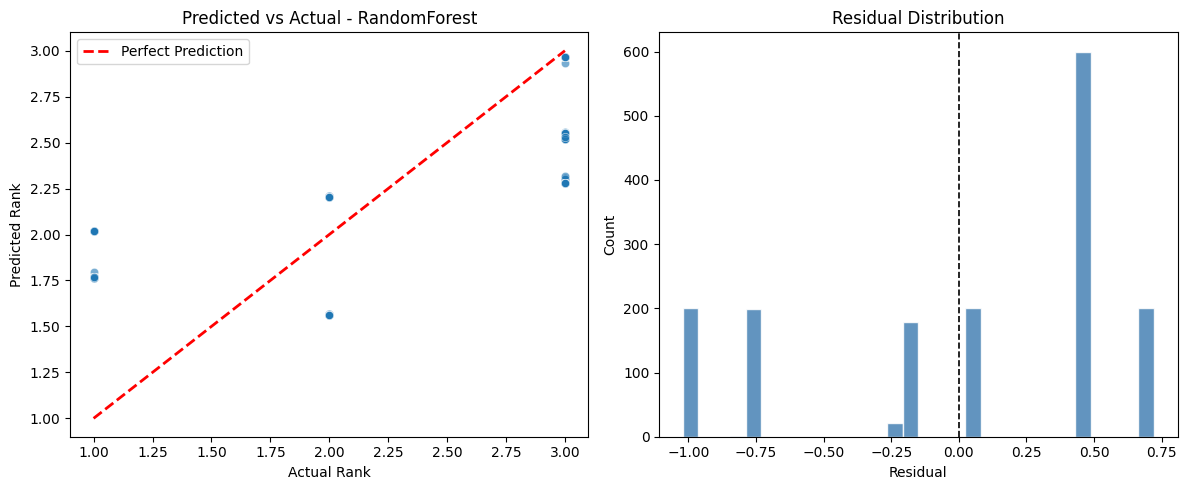

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].scatter(y_test, y_pred_test, alpha=0.6, edgecolors='w', linewidth=0.5)
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Rank")
axes[0].set_ylabel("Predicted Rank")
axes[0].set_title(f"Predicted vs Actual - {best_model_name}", fontsize=12)
axes[0].legend()

residuals = y_test - y_pred_test
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "prediction_rank_residuals.png"), dpi=150)
plt.show()

## 12. Save Model and Feature List

In [14]:
model_path = os.path.join(MODELS_DIR, f"best_{best_model_name.lower()}_rank_predictor.joblib")
joblib.dump(best_model, model_path)
print(f"💾 Saved model ")

💾 Saved model 
